## Import libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, Lasso
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import RobustScaler

# sklearn functions for evaluating regressors
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, max_error, root_mean_squared_error, PredictionErrorDisplay 

# dummy models for baseline
from sklearn.dummy import DummyRegressor

## Preparing the data

In [3]:
df = pd.read_parquet("DKHousingPrices.parquet", engine='fastparquet')
#df = pd.read_csv("DKHousingPricesSample100k.csv")

In [4]:
print(df["date"].min(), "to", df["date"].max())

1992-01-05 00:00:00 to 2024-10-26 00:00:00


In [5]:
#Drop all rows with na in the sqm column
df = df.dropna(subset=["city", "quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "area", "dk_ann_infl_rate%", "nom_interest_rate%", "yield_on_mortgage_credit_bonds%"])
df.head()

,date,quarter,house_id,house_type,sales_type,year_build,purchase_price,%_change_between_offer_and_purchase,no_rooms,sqm,sqm_price,address,zip_code,city,area,region,nom_interest_rate%,dk_ann_infl_rate%,yield_on_mortgage_credit_bonds%
1193,2024-09-30,218,1300,Apartment,regular_sale,1971,1765000,0.0,3,78.0,22628.205078,"Hedekæret 38, 1. th",2640,Hedehusene,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1194,2024-09-30,218,1307,Summerhouse,regular_sale,2009,590939,0.0,3,50.0,11818.780273,Violstien 11,2635,Ishøj,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1195,2024-09-30,218,1301,Apartment,regular_sale,1940,1750000,0.0,2,56.0,31250.000000,"Buddingevej 72I, st. tv",2800,Kongens Lyngby,"Capital, Copenhagen",Zealand,3.35,1.13,4.34
1196,2024-09-30,218,1302,Summerhouse,family_sale,1950,1080000,0.0,4,72.0,15000.000000,Frederiksvej 35,3730,Nexø,Bornholm,Bornholm,3.35,1.13,4.34
1197,2024-09-30,218,1303,Apartment,regular_sale,1974,2300000,0.0,1,50.0,46000.000000,"Thyrasgade 4, 4. 508",2200,København N,"Capital, Copenhagen",Zealand,3.35,1.13,4.34


#### Quarter skal laves til en int istedet for datetime

In [6]:
# Brug denne for hele parquet datasættet
#Convert a Period column to the number of days/months/years since a reference date
df["quarter"] = df["quarter"].astype("int64")
df["zip_code"] = df["zip_code"].astype("category")

In [6]:
#Brug denne for 100KSample
# Convert 'quarter' strings like '2024Q3' into a numeric period representation
# Inspect current dtype and a few values
#print('quarter dtype:', df['quarter'].dtype)
#print(df['quarter'].head())
# Create a PeriodIndex with quarterly frequency, keep the Period object in a helper column
#df['quarter_period'] = pd.PeriodIndex(df['quarter'], freq='Q')
# Option A: use integer period ordinal (small integer per quarter) — convenient for regression
#df['quarter'] = df['quarter_period'].astype('int')
# Option B (alternative): convert to a timestamp for the quarter start (datetime)
# df['quarter'] = df['quarter_period'].to_timestamp()
#df.head()


### Make dummy variables

In [8]:
# We set drop_first=True to avoid the dummy variable trap
df = df.sample(frac=0.2, random_state=42).copy()
X = pd.get_dummies(df[["quarter","house_type", "sales_type", "year_build", "no_rooms", "sqm", "zip_code", "nom_interest_rate%" ]], drop_first=True)
y = df["purchase_price"]
X.shape, y.shape
X.head()

,quarter,year_build,no_rooms,sqm,nom_interest_rate%,house_type_Farm,house_type_Summerhouse,house_type_Townhouse,house_type_Villa,sales_type_auction,...,zip_code_9830,zip_code_9850,zip_code_9870,zip_code_9881,zip_code_9900,zip_code_9940,zip_code_9970,zip_code_9981,zip_code_9982,zip_code_9990
465021,199,1974,5,129.0,0.00,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
742767,181,1968,6,148.0,0.00,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
1167754,139,2006,3,128.0,2.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1051169,149,2003,5,149.0,3.75,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
412051,201,1968,4,86.0,0.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


### Training and test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## Creating a baseline

This baselines is based on the mean value from the dataset

In [9]:
dm = DummyRegressor(strategy='mean')
dm.fit(X_train, y_train)

,strategy,'mean'
,constant,None
,quantile,None


In [10]:
dm_y_pred = dm.predict(X_test)

In [11]:
print("Score on training set: {:.3f}".format(dm.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(dm.score(X_test, y_test)))

Score on training set: 0.000
Score on test set: -0.000


## Linear Regression Model

Make the training and testing split

In [12]:
# Create and fit the model
lr = LinearRegression()
lr_y_pred = lr.fit(X_train, y_train).predict(X_test)

In [13]:
#Evaluate the model
print("Score on training set: {:.3f}".format(lr.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(lr.score(X_test, y_test)))

Score on training set: 0.418
Score on test set: 0.408


In [14]:
# Extract the coefficients
coefficients = lr.coef_

# Get the names of the dummy variable columns
column_names = X.columns

# Create a dictionary with column names as keys and coefficients as values
coef_dict = dict(zip(column_names, coefficients))

# Print the dictionary
print(coef_dict)

{'quarter': np.float64(15266.59607662063), 'year_build': np.float64(-86.95149223773114), 'no_rooms': np.float64(47052.20079093516), 'sqm': np.float64(9676.253445925446), 'nom_interest_rate%': np.float64(33007.5611848), 'house_type_Farm': np.float64(506694.6839828705), 'house_type_Summerhouse': np.float64(-150504.22743234725), 'house_type_Townhouse': np.float64(-123807.85005260672), 'house_type_Villa': np.float64(-515465.76264125353), 'sales_type_auction': np.float64(-167148.04383681202), 'sales_type_family_sale': np.float64(-362893.6323733026), 'sales_type_other_sale': np.float64(-31954.695826671305), 'sales_type_regular_sale': np.float64(34749.25546983909), 'zip_code_1051': np.float64(2521200.313288228), 'zip_code_1052': np.float64(1369361.4592580744), 'zip_code_1053': np.float64(-3.771856427192688e-08), 'zip_code_1054': np.float64(3446984.2961869333), 'zip_code_1055': np.float64(4349864.83925337), 'zip_code_1057': np.float64(2083803.1047457263), 'zip_code_1058': np.float64(3434298.12

In [15]:
display = PredictionErrorDisplay.from_predictions(y_test, lr_y_pred)

KeyboardInterrupt: 

## Lasso Regression

In [ ]:
#lasso = Lasso()
#lasso_params = {'alpha': [0.1, 1.0, 10.0, 100.0]}
#lasso_grid = GridSearchCV(lasso, lasso_params, cv=5)
#lasso_pred = lasso_grid.fit(X_train, y_train).predict(X_test)

In [ ]:
#Evaluate the model
#print("Score on training set: {:.3f}".format(lasso.score(X_train, y_train)))
#print("Score on test set: {:.3f}".format(lasso.score(X_test, y_test)))

## Polynomial Regression Model

We use the code below to create polynomial features on the training data to the degree of 5. 

In [ ]:
# Let's try with degree 2 instead of 3 to reduce memory usage
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)  # Only transform, don't fit again

MemoryError: Unable to allocate 767. GiB for an array with shape (226007, 455535) and data type float64

In [ ]:
# Create and fit the model
poly_lr = LinearRegression()
pr_y_pred = poly_lr.fit(X_train_poly,y_train).predict(X_test_poly)

Evaluating the model

In [ ]:
print("Score on training set: {:.3f}".format(poly_lr.score(X_train_poly, y_train)))
print("Score on test set: {:.3f}".format(poly_lr.score(X_test_poly, y_test)))

Score on training set: 0.396
Score on test set: 0.396


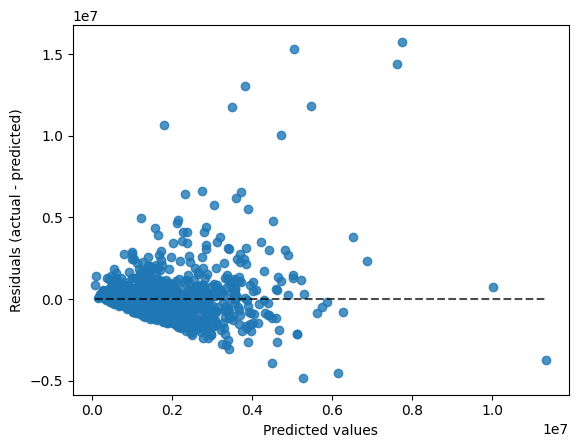

In [ ]:
display = PredictionErrorDisplay.from_predictions(y_test, pr_y_pred)

## Grid Search CV

In [ ]:
# split the data into training and testing sets
#X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42)

# set up the parameter grid - what values should we check for the polynomial degree?
#param_grid = {
#    'poly_features__degree': [1, 2, 3, 4, 5]
#}
#
## create the pipeline with PolynomialFeatures and LinearRegression
#model = Pipeline([
#    ('poly_features', PolynomialFeatures()),
#    ('lin_reg', LinearRegression())
#])
#
## set up GridSearchCV with the model and parameter grid
#grid_search = GridSearchCV(model, param_grid, cv=10, scoring='r2', n_jobs=-1)
#
## fit the grid search to the training data
#grid_search.fit(X_train, y_train)
#
## retrieve and print the scores for each iteration
#cv_results = grid_search.cv_results_
#for mean_score, params in zip(cv_results["mean_test_score"], cv_results["params"]):
#    print(f"Mean R-squared for {params}: {mean_score}")
#
## retrieve the best hyperparameters and the corresponding best estimator
#best_degree = grid_search.best_params_['poly_features__degree']
#best_model = grid_search.best_estimator_
#
## print the best hyperparameters
#print(f"Best Polynomial Degree: {best_degree}")
#
## evaluate the best model on the test data
#test_score = best_model.score(X_test, y_test)
#print(f"Test R-squared with best model: {test_score}")

## KNN Model

In [12]:
knn = KNeighborsRegressor()
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [13]:
# print scores
print("Score on training set: {:.3f}".format(knn.score(X_train, y_train)))
print("Score on test set: {:.3f}".format(knn.score(X_test, y_test)))

: 

In [ ]:
knn_scaled = KNeighborsRegressor()
knn_scaled.fit(X_train_scaled, y_train)

In [10]:
scaler = StandardScaler() # define the scaler
X_train_scaled = scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_scaled = scaler.transform(X_test) # apply to the testing feature matrix

In [ ]:
print("Score on training set: {:.3f}".format(knn_scaled.score(X_train_scaled, y_train)))
print("Score on test set: {:.3f}".format(knn_scaled.score(X_test_scaled, y_test)))

In [11]:
robust_scaler = RobustScaler() # define the scaler
X_train_robust = robust_scaler.fit_transform(X_train) # apply to the training feature matrix
X_test_robust = robust_scaler.transform(X_test) # apply to the testing feature matrix

In [ ]:
knn_robust = KNeighborsRegressor()
knn_robust.fit(X_train_robust, y_train)

In [ ]:
print("Score on training set: {:.3f}".format(knn_robust.score(X_train_robust, y_train)))
print("Score on test set: {:.3f}".format(knn_robust.score(X_test_robust, y_test)))

## Evaluation
This will be done based on MAE, MAPE, MSE, RMSE and Max

In [ ]:
# this is a function that takes actual y values (y_true) and predicted y values (y_pred) and calculates MAE, MAPE, MSE, and RMSE
def get_metrics(y_true, y_pred):
    
    # MAE: the average of the absolute differences between the actual values and the predicted values
    mae = mean_absolute_error(y_true, y_pred)
    
    # MAPE: the average absolute percentage difference between the actual and predicted values
    mape = mean_absolute_percentage_error(y_true, y_pred)
    
    # MSE: the average of the squared differences between the actual values and the predicted values
    mse = mean_squared_error(y_true, y_pred)
    
    # RMSE: the square root of MSE
    rmse = mean_squared_error(y_true, y_pred)

    # Max error: the average absolute percentage difference between the actual and predicted values
    max = max_error(y_true, y_pred)
    
    # return all four metrics
    return mae, mape, mse, rmse, max

In [ ]:
# calculate the metrics for each model using our `get_metrics` function.
dm_metrics = get_metrics(y_test, dm_y_pred)  # for dummy regressor
lr_metrics = get_metrics(y_test, lr_y_pred)  # for linear regression
pr_metrics = get_metrics(y_test, pr_y_pred)  # for linear regression
#lasso_metrics = get_metrics(y_test, lasso_pred)  # for lasso regression
#kn_metrics = get_metrics(y_test, kn_y_pred)  # for KNN regressor
#rf_metrics = get_metrics(y_test, rf_y_pred)  # for random forest regressor

In [ ]:
# create a dataframe (table) to store and display the computed metrics where each row represents a different model and each column represents a different metric
results = pd.DataFrame({
    'Model': ['Dummy', 'Linear Regression', 'PR'],  # model names
    'MAE': [dm_metrics[0], lr_metrics[0], pr_metrics[0]],  # MAE values for each model
    'MAPE': [dm_metrics[1], lr_metrics[1], pr_metrics[1]],  # MAPE values for each model
    'MSE': [dm_metrics[2], lr_metrics[2], pr_metrics[2]],  # MSE values for each model
    'RMSE': [dm_metrics[3], lr_metrics[3], pr_metrics[3]], # RMSE values for each model
    'Max': [dm_metrics[4], lr_metrics[4], pr_metrics[4]] # Max error values for each model

})

# display results
results

,Model,MAE,MAPE,MSE,RMSE,Max
0,Dummy,1.186556e+06,1.082663,3.127559e+12,3.127559e+12,4.408389e+07
1,Linear Regression,9.615007e+05,0.788307,2.222019e+12,2.222019e+12,3.781911e+07
2,PR,8.597532e+05,0.683105,1.888288e+12,1.888288e+12,4.382627e+07


### Results
**Mean Absolute Error (MAE):**

PR performs best (lowest MAE: 808,086), followed by Linear Regression (916,957), and Dummy (1,186,556).
PR reduces MAE by ~12% compared to Linear Regression and ~32% compared to Dummy.



**Mean Absolute Percentage Error (MAPE):**

PR has the lowest MAPE (0.631), indicating better relative accuracy.
Linear Regression (0.737) and Dummy (1.083) perform worse.



**Mean Squared Error (MSE) and Root Mean Squared Error (RMSE):**

PR has the lowest MSE and RMSE, suggesting it handles large errors better than the other models.
Dummy has the highest MSE/RMSE, as expected.



**Max Error:**

PR has the highest max error (45,704,040), but this is likely an outlier and does not reflect overall performance.
Linear Regression has the lowest max error (38,035,220).